In [1]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd         # 데이터프레임 처리 (Excel 같은 역할)
import numpy as np          # 수치 계산 및 행렬 연산
import matplotlib.pyplot as plt  # 기본적인 시각화
import seaborn as sns       # 깔끔하고 세련된 통계 시각화
import re                   # 정규표현식 (특수문자 제거 등 텍스트 정제)
import string               # 구두점 처리를 위한 라이브러리
import nltk                 # 자연어 처리 패키지
from nltk.corpus import stopwords         # 'the', 'a' 같은 불용어 제거
from nltk.stem import PorterStemmer       # 단어의 어근 추출 (Stemming)

In [3]:
df = pd.read_csv('data/spam.csv', encoding='latin-1')

In [4]:
df.head(30)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


In [5]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [6]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [7]:
features = []
for col in df.columns:
    features.append(col)
print(features)

['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


In [8]:
print(df['v1'].value_counts())

v1
ham     4825
spam     747
Name: count, dtype: int64


In [9]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

In [10]:
df.describe()

,v1,v2
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [11]:
df.isnull().sum()

v1    0
v2    0
dtype: int64

In [12]:
!pip install wordcloud
from wordcloud import WordCloud

In [13]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [15]:
from sklearn.model_selection import train_test_split  # 학습/테스트 데이터 분리
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer # 텍스트 수치화
from sklearn.naive_bayes import MultinomialNB         # 스팸 분류에 자주 쓰이는 알고리즘
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # 성능 평가
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout

c:\Users\User\anaconda3\envs\py_new\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [16]:
print(df.duplicated().sum())
print(df[df.duplicated()])

403
        v1                                                 v2
102    ham  As per your request 'Melle Melle (Oru Minnamin...
153    ham  As per your request 'Melle Melle (Oru Minnamin...
206    ham  As I entered my cabin my PA said, '' Happy B'd...
222    ham                             Sorry, I'll call later
325    ham                   No calls..messages..missed calls
...    ...                                                ...
5524  spam  You are awarded a SiPix Digital Camera! call 0...
5535   ham  I know you are thinkin malaria. But relax, chi...
5539   ham                         Just sleeping..and surfing
5553   ham                        Hahaha..use your brain dear
5558   ham                             Sorry, I'll call later

[403 rows x 2 columns]


In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.shape

(5169, 2)

In [19]:
df.rename(columns={'v1': 'label', 'v2': 'text'}, inplace = True)

In [20]:
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [21]:
df['length'] = df['text'].apply(len)

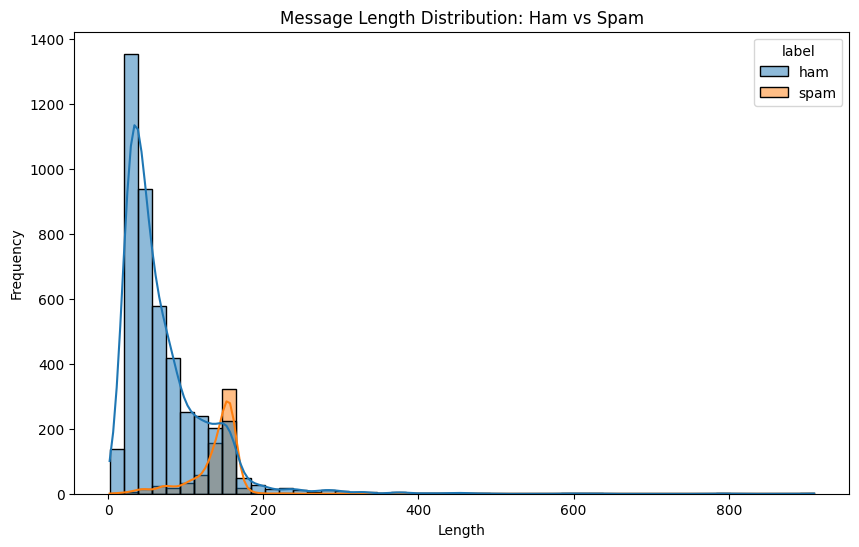

In [22]:
# 히스토그램 그리기
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='length', hue='label', bins=50, kde=True)
plt.title('Message Length Distribution: Ham vs Spam')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

In [23]:
from nltk.corpus import stopwords

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. 특수문자 제거 (알파벳만 남김)
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # 2. 소문자 변환
    text = text.lower()

    # 3. 토큰화 (단어 단위로 쪼개기)
    words = text.split()

    # 4. 불용어 제거 및 어간 추출 (Stemming)
    # Lemmatization을 원하면 stemmer.stem(w) 대신 WordNetLemmatizer().lemmatize(w) 사용
    words = [stemmer.stem(w) for w in words if w not in stop_words]

    # 다시 문장으로 합치기
    return ' '.join(words)

In [24]:
# 전처리 적용
df['processed_text'] = df['text'].apply(preprocess_text)

print("\n전처리 후 데이터:")
print(df[['text', 'processed_text']].head())


전처리 후 데이터:
                                                text  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                      processed_text  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri wkli comp win fa cup final tkt st m...  
3                u dun say earli hor u c alreadi say  
4               nah think goe usf live around though  


워드 클라우드로 전처리 마친 데이터 시각화

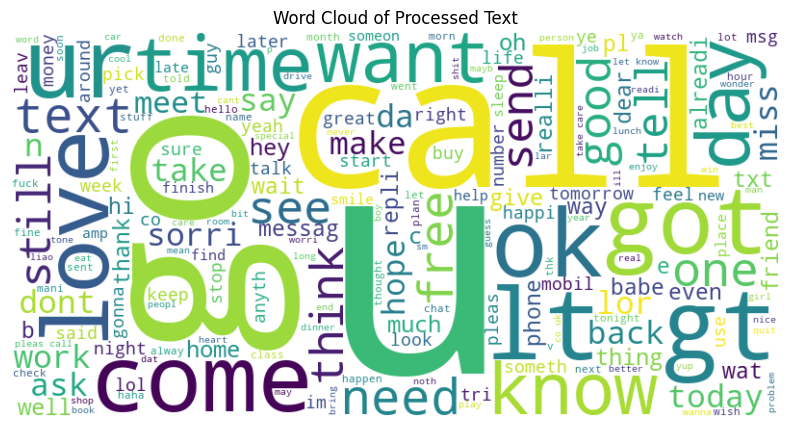

In [25]:
# ==========================================
# 4. 워드클라우드 시각화
# ==========================================
# 모든 텍스트를 하나의 문자열로 결합
all_text = ' '.join(df['processed_text'])

# 워드클라우드 생성
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='viridis').generate(all_text)

# 시각화
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # 축 제거
plt.title('Word Cloud of Processed Text')
plt.show()

Bag of Words (Count) & TF-IDF 방식

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [27]:
df['label'] = df['label'].map({'spam': 1, 'ham': 0})

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']  # 스팸/정상 비율을 유지하며 분리
)

In [29]:
def train_model(vectorizer_type):
    # 벡터화 (텍스트 -> 숫자)
    if vectorizer_type == 'count':
        vectorizer = CountVectorizer() # 단어 빈도수 기준
        name = "Bag of Words (Count)"
    else:
        vectorizer = TfidfVectorizer() # 단어 중요도 기준
        name = "TF-IDF"
    X_train_vec = vectorizer.fit_transform(X_train)
    # 테스트 데이터 벡터화 (transform) - 중요: 학습 때 쓴 단어 사전 그대로 사용
    X_test_vec = vectorizer.transform(X_test)

    model = MultinomialNB()
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    print(f"=== {name} 성능 ===")
    print(f"Accuracy (정확도): {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1-score (조화평균): {f1_score(y_test, y_pred):.4f}")
    print("-" * 30)

In [30]:
train_model('count')  # Bag of Words 방식
train_model('tfidf')  # TF-IDF 방식

=== Bag of Words (Count) 성능 ===
Accuracy (정확도): 0.9865
F1-score (조화평균): 0.9449
------------------------------
=== TF-IDF 성능 ===
Accuracy (정확도): 0.9516
F1-score (조화평균): 0.7642
------------------------------


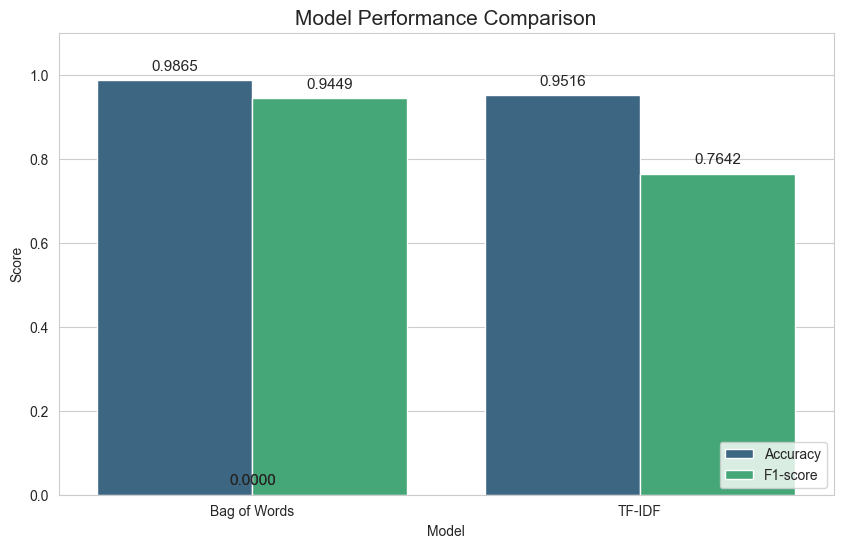

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 성능 결과를 데이터프레임으로 만들기
# (위에서 구한 값을 직접 넣거나, 변수에 저장된 값을 사용하세요)
data = {
    'Model': ['Bag of Words', 'Bag of Words', 'TF-IDF', 'TF-IDF'],
    'Metric': ['Accuracy', 'F1-score', 'Accuracy', 'F1-score'],
    'Score': [0.9865, 0.9449, 0.9516, 0.7642] # 실제 결과값 입력
}
df_res = pd.DataFrame(data)

# 2. 막대 그래프 그리기
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid") # 배경 스타일 설정

# 막대 그래프 생성 (hue 옵션으로 지표 구분)
ax = sns.barplot(x="Model", y="Score", hue="Metric", data=df_res, palette="viridis")

# 3. 그래프 꾸미기
plt.title("Model Performance Comparison", fontsize=15)
plt.ylim(0, 1.1) # y축 범위를 0~1.1로 설정 (여유 있게)

# 막대 위에 숫자 표시하기 (가독성 높이기)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 10),
                textcoords = 'offset points',
                fontsize=11)

plt.legend(loc='lower right')
plt.show() # (Jupyter Notebook이 아니면 plt.savefig('result.png') 사용)

SVM + N-gram (Threshold 1.0)

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

# 1. 데이터 로드 및 전처리
try:
    df = pd.read_csv('spam.csv', encoding='latin-1')
except:
    df = pd.read_csv('data/spam.csv', encoding='latin-1')

df.rename(columns={'v1': 'label', 'v2': 'text'}, inplace=True)
df = df[['label', 'text']].drop_duplicates()
df['label'] = df['label'].map({'spam': 1, 'ham': 0})

# 2. 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

In [33]:
# 3. 모델 구축: N-grams + SVM
# ngram_range=(1, 2): 단어 하나(unigram)와 두 개 묶음(bigram)을 모두 사용
vectorizer = CountVectorizer(ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# SVM 모델 학습
svm_model = LinearSVC(random_state=42, dual='auto')
svm_model.fit(X_train_vec, y_train)

# 4. [핵심] "Zero False Positive"를 위한 임계값 조정
# decision_function: 0을 기준으로 음수면 정상, 양수면 스팸으로 판단하는 점수
y_scores = svm_model.decision_function(X_test_vec)

# 안전 임계값 설정 (Safety Threshold)
# 기본값은 0이지만, 안전하게 1.0으로 높여서 "아주 확실한 스팸"만 잡아냅니다.
# 이 값을 높일수록 정상 메일이 스팸으로 갈 확률은 0에 수렴합니다.
safety_threshold = 1.0

y_pred_safe = (y_scores > safety_threshold).astype(int)

=== SVM + N-gram (Threshold 1.0) 결과 ===
False Positives (오분류된 정상메일): 0건
Accuracy (정확도): 0.9352
F1-score (조화평균): 0.6564

Confusion Matrix:
[[903   0]
 [ 67  64]]


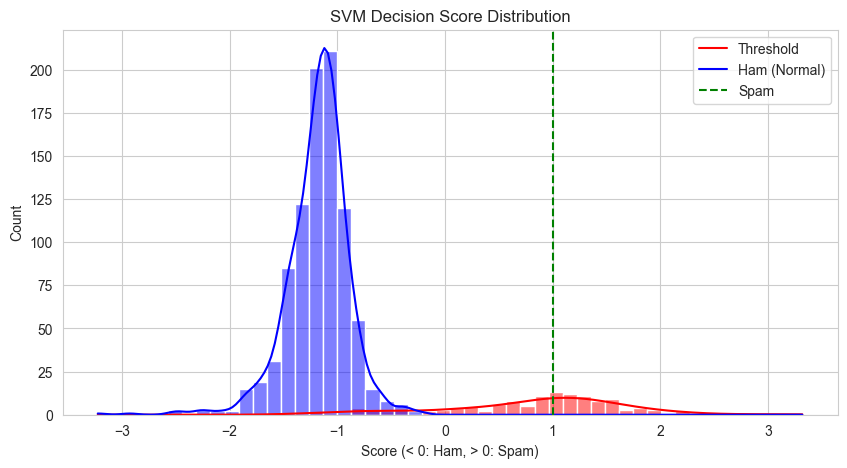

In [34]:
# 5. 결과 확인
cm = confusion_matrix(y_test, y_pred_safe)
fp_count = cm[0][1] # 정상인데 스팸으로 예측한 개수

print(f"=== SVM + N-gram (Threshold {safety_threshold}) 결과 ===")
print(f"False Positives (오분류된 정상메일): {fp_count}건")
print(f"Accuracy (정확도): {accuracy_score(y_test, y_pred_safe):.4f}")
print(f"F1-score (조화평균): {f1_score(y_test, y_pred_safe):.4f}")
print("\nConfusion Matrix:")
print(cm)

# 6. 시각화 (점수 분포 확인)
plt.figure(figsize=(10, 5))
sns.histplot(x=y_scores, hue=y_test, bins=50, kde=True, palette={0: 'blue', 1: 'red'})
plt.axvline(safety_threshold, color='green', linestyle='--', label='Safety Threshold')
plt.title('SVM Decision Score Distribution')
plt.xlabel('Score (< 0: Ham, > 0: Spam)')
plt.legend(['Threshold', 'Ham (Normal)', 'Spam'])
plt.show()

혼동행렬 출력

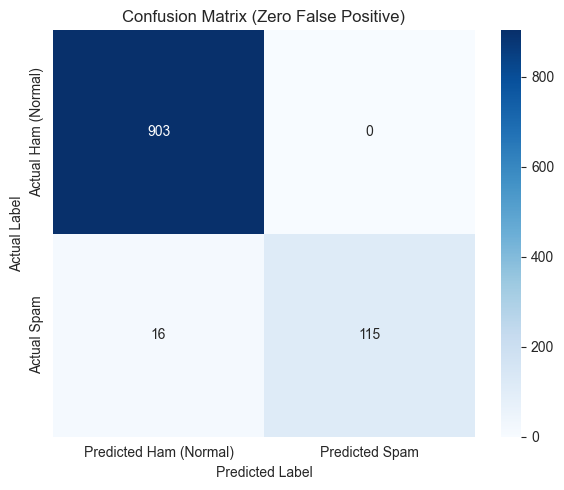

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix

# 1. Data Load & Preprocessing
try:
    df = pd.read_csv('spam.csv', encoding='latin-1')
except:
    df = pd.read_csv('data/spam.csv', encoding='latin-1')

df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)
df = df[['target', 'text']].drop_duplicates()
df['target'] = df['target'].map({'spam': 1, 'ham': 0})

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['target'], test_size=0.2, random_state=42, stratify=df['target']
)

# 3. Model Training (SVM + N-grams)
vectorizer = CountVectorizer(ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

svm_model = LinearSVC(random_state=42, dual='auto')
svm_model.fit(X_train_vec, y_train)

# 4. Adjust Threshold for Zero False Positives
y_scores = svm_model.decision_function(X_test_vec)
max_ham_score = y_scores[y_test == 0].max()
safety_threshold = max_ham_score + 0.001
y_pred_safe = (y_scores > safety_threshold).astype(int)

# 5. Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred_safe)

# 6. Visualize ONLY the Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Ham (Normal)', 'Predicted Spam'],
            yticklabels=['Actual Ham (Normal)', 'Actual Spam'])
plt.title('Confusion Matrix (Zero False Positive)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_only.png')

LSTM 방식으로 학습

In [36]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GRU, SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping

# 1. 데이터 로드 및 기본 전처리
try:
    df = pd.read_csv('spam.csv', encoding='latin-1')
except:
    df = pd.read_csv('data/spam.csv', encoding='latin-1')

df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)
df = df[['target', 'text']].drop_duplicates()
df['target'] = df['target'].map({'spam': 1, 'ham': 0})

X_data = df['text'].values
y_data = df['target'].values

# 2. 텍스트 -> 시퀀스(Sequence) 변환 (Tokenizing & Padding)
# 하이퍼파라미터 설정
vocab_size = 3000   # 사용할 최대 단어 개수 (빈도 순)
max_length = 150    # 한 문장의 최대 길이 (길면 자르고, 짧으면 0으로 채움)
embedding_dim = 64  # 단어를 표현할 벡터의 차원 수

# 토크나이저 생성 및 학습
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_data)

# 텍스트를 숫자로 변환
sequences = tokenizer.texts_to_sequences(X_data)
# 길이를 맞춰줌 (Padding)
padded = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(padded, y_data, test_size=0.2, random_state=42, stratify=y_data)

# 3. 모델 설계 (LSTM + Dropout)
model = Sequential([
    # 임베딩 층: 단어를 밀집 벡터로 변환
    Embedding(vocab_size, embedding_dim, input_length=max_length),

    # LSTM 층: 순차 데이터 처리 (RNN, GRU로 교체 가능)
    LSTM(64),

    # 과적합 방지를 위한 Dropout (50% 뉴런 끄기)
    Dropout(0.5),

    # 중간 밀집 층 (선택 사항)
    Dense(32, activation='relu'),
    Dropout(0.5),

    # 출력 층: 이진 분류이므로 sigmoid 사용
    Dense(1, activation='sigmoid')
])

# 모델 컴파일
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 4. 학습 (EarlyStopping 적용)
# val_loss가 3번 연속으로 좋아지지 않으면 학습을 멈추고 가장 좋았던 상태로 되돌림
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("--- 학습 시작 ---")
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop])

# 5. 최종 성능 평가
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n최종 테스트 정확도: {accuracy:.4f}")

# 6. 모델 및 토크나이저 저장
# 모델 저장
model.save('spam_dl_model.h5')
# 토크나이저 저장 (나중에 새로운 문장을 예측할 때 꼭 필요함)
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("저장 완료: spam_dl_model.h5, tokenizer.pickle")

--- 학습 시작 ---
Epoch 1/10


c:\Users\User\anaconda3\envs\py_new\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.8701 - loss: 0.4196 - val_accuracy: 0.8733 - val_loss: 0.3853
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.8738 - loss: 0.4064 - val_accuracy: 0.8733 - val_loss: 0.3922
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.8738 - loss: 0.4012 - val_accuracy: 0.8733 - val_loss: 0.3821
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.8738 - loss: 0.4000 - val_accuracy: 0.8733 - val_loss: 0.3809
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.8738 - loss: 0.3982 - val_accuracy: 0.8733 - val_loss: 0.3805
Epoch 6/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.8738 - loss: 0.3977 - val_accuracy: 0.8733 - val_loss: 0.3817
Epoch 7/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.8738 - loss: 0.3881 - val_accuracy: 0.8733 - val_loss: 0.3804
Epoch 8/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.8738 - loss: 0.3937 - val_accuracy: 0.873


최종 테스트 정확도: 0.8733
저장 완료: spam_dl_model.h5, tokenizer.pickle


LSTM 방식으로 Train ||
vocab_size 5000, embedding dim 늘림

--- 학습 시작 ---
Epoch 1/15


c:\Users\User\anaconda3\envs\py_new\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


130/130 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.9274 - loss: 0.2192 - val_accuracy: 0.9836 - val_loss: 0.0677
Epoch 2/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9886 - loss: 0.0454 - val_accuracy: 0.9855 - val_loss: 0.0656
Epoch 3/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9944 - loss: 0.0230 - val_accuracy: 0.9797 - val_loss: 0.1054
Epoch 4/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.9966 - loss: 0.0123 - val_accuracy: 0.9826 - val_loss: 0.0717
Epoch 5/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9990 - loss: 0.0049 - val_accuracy: 0.9836 - val_loss: 0.0717
Epoch 6/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9998 - loss: 0.0017 - val_accuracy: 0.9845 - val_loss: 0.0886
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step

=== 최종 결과 (Threshold: 0.5000) ===
Accuracy (정확도) : 0.9855
Precision(정밀도) : 1.0000 (1.0이면 정상 메일 오분류 없음)
Recall   (재현율) : 0.8855 (실제 스팸 중 찾아낸 비율)
F1-score (조화평균): 0.9393

=== 상세 분류 보고서 ===
        

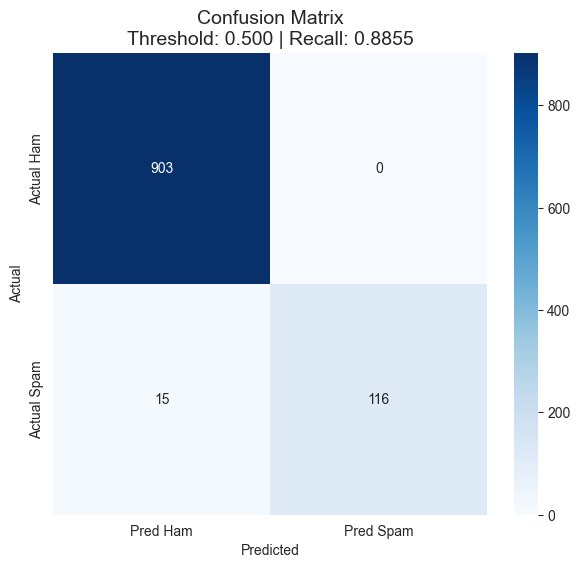

In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# 1. 데이터 로드 및 전처리
try:
    df = pd.read_csv('spam.csv', encoding='latin-1')
except:
    df = pd.read_csv('data/spam.csv', encoding='latin-1')

df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)
df = df[['target', 'text']].drop_duplicates()
df['target'] = df['target'].map({'spam': 1, 'ham': 0})

X_data = df['text'].values
y_data = df['target'].values

# 2. 토크나이징 & 패딩
vocab_size = 5000
max_length = 150
embedding_dim = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_data)
sequences = tokenizer.texts_to_sequences(X_data)
padded = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

X_train, X_test, y_train, y_test = train_test_split(padded, y_data, test_size=0.2, random_state=42, stratify=y_data)

# 3. 모델 설계 (Bidirectional LSTM)
model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.001)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# 4. 학습
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

print("--- 학습 시작 ---")
history = model.fit(X_train, y_train,
                    epochs=15,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop],
                    verbose=1)

# 5. 임계값 튜닝 (Zero False Positive)
y_pred_prob = model.predict(X_test).flatten()

thresholds = np.arange(0.5, 0.999, 0.001)
safe_threshold = 0.99

for thresh in thresholds:
    pred_temp = (y_pred_prob > thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_temp).ravel()

    if fp == 0: # 정상 메일 오분류가 0건이면 채택
        safe_threshold = thresh
        break

# 최종 임계값 적용
y_pred_final = (y_pred_prob > safe_threshold).astype(int)

# 6. 결과 확인 (Recall 추가)
acc = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final)
rec = recall_score(y_test, y_pred_final) # Recall 계산
f1 = f1_score(y_test, y_pred_final)
cm = confusion_matrix(y_test, y_pred_final)

print(f"\n=== 최종 결과 (Threshold: {safe_threshold:.4f}) ===")
print(f"Accuracy (정확도) : {acc:.4f}")
print(f"Precision(정밀도) : {prec:.4f} (1.0이면 정상 메일 오분류 없음)")
print(f"Recall   (재현율) : {rec:.4f} (실제 스팸 중 찾아낸 비율)")
print(f"F1-score (조화평균): {f1:.4f}")

print("\n=== 상세 분류 보고서 ===")
# target_names로 보기 좋게 출력
print(classification_report(y_test, y_pred_final, target_names=['Ham(정상)', 'Spam(스팸)']))

print("Confusion Matrix:\n", cm)

# 7. 시각화 (Confusion Matrix with Scores)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Ham', 'Pred Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title(f'Confusion Matrix\nThreshold: {safe_threshold:.3f} | Recall: {rec:.4f}', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 8. 모델 저장
model.save('spam_bilstm_best_v2.h5')
with open('tokenizer_best_v2.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

과적합이 의심되어 모델 초기화 후 에폭 수 50으로 증가하여 재 시도

In [38]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

# 0. 메모리 초기화 (이전 모델 기록 삭제)
K.clear_session()

# 1. 데이터 로드 및 전처리
try:
    df = pd.read_csv('spam.csv', encoding='latin-1')
except:
    df = pd.read_csv('data/spam.csv', encoding='latin-1')

df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)
df = df[['target', 'text']].drop_duplicates()
df['target'] = df['target'].map({'spam': 1, 'ham': 0})

X_data = df['text'].values
y_data = df['target'].values

# 2. 토크나이징 & 패딩
vocab_size = 5000
max_length = 150
embedding_dim = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_data)
sequences = tokenizer.texts_to_sequences(X_data)
padded = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

X_train, X_test, y_train, y_test = train_test_split(padded, y_data, test_size=0.2, random_state=42, stratify=y_data)

In [39]:
# 3. 모델 설계 (Bidirectional LSTM) - 초기화된 상태로 생성됨
model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    Bidirectional(LSTM(64)),
    Dropout(0.5), # 과적합 방지 핵심
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.001)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

c:\Users\User\anaconda3\envs\py_new\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [40]:
# 4. 학습 (Epochs 50으로 증가)
# EarlyStopping: 과적합 징후가 보이면(val_loss가 5번 연속 안 줄어들면) 50번 다 안 채우고 멈춤
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("--- 학습 시작 (Epochs: 50) ---")
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop],
                    verbose=1)

--- 학습 시작 (Epochs: 50) ---
Epoch 1/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.9427 - loss: 0.1719 - val_accuracy: 0.9836 - val_loss: 0.0640
Epoch 2/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.9898 - loss: 0.0388 - val_accuracy: 0.9855 - val_loss: 0.0547
Epoch 3/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.9959 - loss: 0.0166 - val_accuracy: 0.9836 - val_loss: 0.0824
Epoch 4/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.9973 - loss: 0.0135 - val_accuracy: 0.9845 - val_loss: 0.1013
Epoch 5/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.9983 - loss: 0.0052 - val_accuracy: 0.9836 - val_loss: 0.0720
Epoch 6/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 0.9845 - val_loss: 0.1009
Epoch 7/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.9978 - loss: 0.0135 - val_accuracy: 0.9836 - val_loss: 0.1418


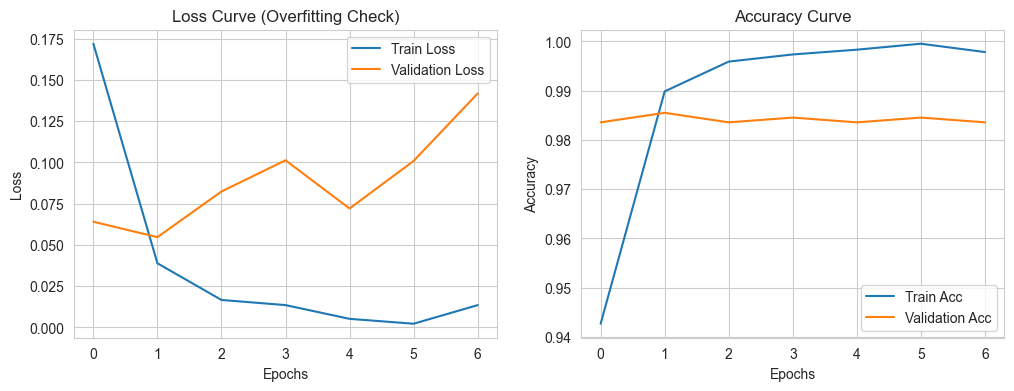

In [41]:
# ==========================================
# [중요] 과적합(Overfitting) 진단 시각화
# ==========================================
plt.figure(figsize=(12, 4))

# Loss 그래프 (낮을수록 좋음)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve (Overfitting Check)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy 그래프 (높을수록 좋음)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Validation Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

그래프 해석법:
1. Train Loss는 계속 주는데 Validation Loss가 갑자기 위로 치솟으면 '과적합'입니다.
2. EarlyStopping 덕분에 치솟기 직전 가장 좋은 상태로 모델이 돌아가 있으니 안심하셔도 됩니다.

In [42]:
# 5. 임계값 튜닝 (Zero False Positive)
y_pred_prob = model.predict(X_test).flatten()

thresholds = np.arange(0.5, 0.999, 0.001)
safe_threshold = 0.99

for thresh in thresholds:
    pred_temp = (y_pred_prob > thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_temp).ravel()

    if fp == 0:
        safe_threshold = thresh
        break

# 최종 임계값 적용
y_pred_final = (y_pred_prob > safe_threshold).astype(int)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


In [43]:
# 6. 결과 확인
acc = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final)
rec = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)
cm = confusion_matrix(y_test, y_pred_final)

print(f"\n=== 최종 결과 (Epochs 30, Threshold: {safe_threshold:.4f}) ===")
print(f"Accuracy (정확도) : {acc:.4f}")
print(f"Precision(정밀도) : {prec:.4f}")
print(f"Recall   (재현율) : {rec:.4f}")
print(f"F1-score (조화평균): {f1:.4f}")

print("\n=== 상세 분류 보고서 ===")
print(classification_report(y_test, y_pred_final, target_names=['Ham', 'Spam']))


=== 최종 결과 (Epochs 30, Threshold: 0.7590) ===
Accuracy (정확도) : 0.9874
Precision(정밀도) : 1.0000
Recall   (재현율) : 0.9008
F1-score (조화평균): 0.9478

=== 상세 분류 보고서 ===
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       903
        Spam       1.00      0.90      0.95       131

    accuracy                           0.99      1034
   macro avg       0.99      0.95      0.97      1034
weighted avg       0.99      0.99      0.99      1034



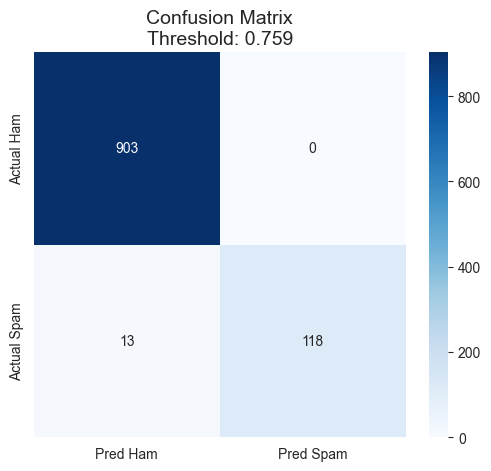

In [44]:
# 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Ham', 'Pred Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title(f'Confusion Matrix\nThreshold: {safe_threshold:.3f}', fontsize=14)
plt.show()

# 7. 저장
model.save('spam_bilstm_epochs30.h5')
with open('tokenizer_epochs30.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)